# FullSubNet Architecture Ablation Study - Multi-Experiment Runner

## Research Objective

Systematically compare architecture changes for speech enhancement to determine which best balances:
1. Perceptual quality (PESQ)
2. Intelligibility (STOI)  
3. Signal quality (SI-SNR)
4. Generalization to unseen noise

## Ablation Study 1: Sequence Model
The FullSubNet implementation offers two different architectures for its `SequenceModel`:

1. **LSTM** - Long Short-Term Memory
2. **GRU** - Gated Recurrent Unit

In addition to the metrics and generalization gap, this ablation will also compare:
- Epoch time
- Training time
- Memory usage

## Ablation Study 2: Dropout
Dropout has been shown to improve generalization by forcing the network to learn different patterns.

We will experiment with different dropout values:

1. `dropout = 0.0` - No dropout
2. `dropout = 0.1` - Drop 10% of neurons during training
3. `dropout = 0.2` - Drop 20% of neurons during training

## Ablation Study 3: Normalization
Normalization can help with generalization since it affects the model's sensitivity scale, loudness and distribution shift across different noise types.

The FullSubNet implementation includes these following `norm_type` options:

1. `offline_laplace_norm` - Default, global mean normalization
2. `cumulatice_laplace_norm` - Causal running mean normalization over time
3. `offline_gaussian_norm` - Global $z$-score normalization

## Experiment Design

- **Fixed**: Dataset, loss function, training procedure
- **Variable**: Architecture
- **Metrics**: PESQ, STOI, SI-SNR + generalization gaps, training time
- **Automation**: Run all experiments sequentially from config list

## How to Use This Notebook

### Switching Between Ablation Studies

Edit the `CURRENT_ABLATION` variable in the Configuration cell above:
- **`CURRENT_ABLATION = 1`**: Sequence Model ablation (LSTM vs GRU) - **includes time metrics**
- **`CURRENT_ABLATION = 2`**: Dropout values (0.0 vs 0.1 vs 0.2)
- **`CURRENT_ABLATION = 3`**: Normalization layers (Offline Laplace vs Cumulative Laplace vs Offline Gaussian)

### Required Config Files

Config files should be placed in `configs/architecture_ablations/` with the following parameters:

**Ablation 1** (Sequence Model):
- `fullsubnet_lstm.yaml` - with `sequence_model: LSTM`
- `fullsubnet_gru.yaml` - with `sequence_model: GRU`

**Ablation 2** (Dropout):
- `fullsubnet_dropout_0.0.yaml` - with `dropout: 0.0`
- `fullsubnet_dropout_0.1.yaml` - with `dropout: 0.1`
- `fullsubnet_dropout_0.2.yaml` - with `dropout: 0.2`

**Ablation 3** (Normalization):
- `fullsubnet_norm_offline_laplace.yaml` - with `norm_type: "offline_laplace_norm"`
- `fullsubnet_norm_cumulative_laplace.yaml` - with `norm_type: "cumulative_laplace_norm"`
- `fullsubnet_norm_offline_gaussian.yaml` - with `norm_type: "offline_gaussian_norm"`

### Output Structure

Results are organized by ablation study:
```
results/
├── fullsubnet_architecture_ablation_1/
│   ├── experiment_name_1/
│   │   ├── checkpoints/
│   │   ├── config.yaml
│   │   ├── training_history.json
│   │   └── evaluation_results.json
│   └── experiment_name_2/
└── fullsubnet_architecture_ablation_2/
    └── ...
```

## Setup and Imports

In [1]:
import os
import sys
import json
import random
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm import tqdm

# Setup paths for modules
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project imports
from src.data.manifest import load_manifest
from src.data.dataset import FullSubNetDataset
from src.models.fullsubnet import FullSubNet
from src.evaluation.evaluate import evaluate_model
from src.evaluation.metrics import validate_with_metrics
from src.training.losses import build_loss

print("✓ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Dataset classes defined
✓ Loss functions defined
✓ All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:
# Configure Seaborn for better visualizations
sns.set_theme(style="whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("\u2713 Seaborn configured for visualization")

✓ Seaborn configured for visualization


## Configuration: List All Experiments to Run

**Add/remove config files here to control which experiments run:**

In [3]:
# ============================================================================
# ARCHITECTURE ABLATION CONFIGURATION
# ============================================================================

# Ablation Study 1: Sequence Model (LSTM vs GRU) + Time Metrics
ABLATION_1_CONFIGS = [
    "configs/architecture_ablations/fullsubnet_lstm.yaml",
    "configs/architecture_ablations/fullsubnet_gru.yaml",
]

# Ablation Study 2: Dropout Values
ABLATION_2_CONFIGS = [
    "configs/architecture_ablations/fullsubnet_dp_00.yaml",
    "configs/architecture_ablations/fullsubnet_dp_01.yaml",
    "configs/architecture_ablations/fullsubnet_dp_02.yaml",
]

# Ablation Study 3: Normalization Layers
ABLATION_3_CONFIGS = [
    "configs/architecture_ablations/fullsubnet_offline_laplace.yaml",
    "configs/architecture_ablations/fullsubnet_cumulative_laplace.yaml",
    "configs/architecture_ablations/fullsubnet_offline_gaussian.yaml",
]

# Select which ablation study to run
CURRENT_ABLATION = 3  # 1, 2, or 3

if CURRENT_ABLATION == 1:
    CONFIG_FILES = ABLATION_1_CONFIGS
    ABLATION_NAME = "Sequence Model (LSTM vs GRU)"
    TRACK_TIME_METRICS = True
elif CURRENT_ABLATION == 2:
    CONFIG_FILES = ABLATION_2_CONFIGS
    ABLATION_NAME = "Dropout Values"
    TRACK_TIME_METRICS = False
elif CURRENT_ABLATION == 3:
    CONFIG_FILES = ABLATION_3_CONFIGS
    ABLATION_NAME = "Normalization Layers"
    TRACK_TIME_METRICS = False
else:
    raise ValueError("CURRENT_ABLATION must be 1, 2, or 3")

# Optional: Skip experiments if they already completed
SKIP_COMPLETED = True

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Device: {DEVICE}")
print(f"Ablation Study: {ABLATION_NAME}")
print(f"Track time metrics: {TRACK_TIME_METRICS}")
print(f"\nExperiments to run: {len(CONFIG_FILES)}")
for i, config_file in enumerate(CONFIG_FILES, 1):
    print(f"  {i}. {config_file}")

Device: cuda
Ablation Study: Normalization Layers
Track time metrics: False

Experiments to run: 3
  1. configs/architecture_ablations/fullsubnet_offline_laplace.yaml
  2. configs/architecture_ablations/fullsubnet_cumulative_laplace.yaml
  3. configs/architecture_ablations/fullsubnet_offline_gaussian.yaml


## Utility Functions

In [4]:
import time
import psutil

def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_config(config_path: str) -> Dict:
    """Load experiment configuration from YAML."""
    with open(PROJECT_ROOT / config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config


def setup_experiment_dirs(config: Dict, ablation_num: int) -> Tuple[Path, Path, Path]:
    """Create experiment directories."""
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
    results_root = PROJECT_ROOT / "results" / f"fullsubnet_architecture_ablation_{ablation_num}"
    results_dir = results_root / config['experiment_name']
    checkpoint_dir = results_dir / "checkpoints"
    plots_dir = PROJECT_ROOT / "plots" / f"architecture_ablation_{ablation_num}" / config['experiment_name']
    
    results_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    
    return results_dir, checkpoint_dir, plots_dir


def is_experiment_complete(results_dir: Path) -> bool:
    """Check if experiment already completed."""
    return (results_dir / 'evaluation_results.json').exists()


def save_config(config: Dict, save_path: Path):
    """Save configuration to file."""
    with open(save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)


def clear_gpu_memory():
    """Best-effort cleanup for low-VRAM experiments."""
    import gc
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()


def get_gpu_memory():
    """Get current GPU memory usage in MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**2
    return 0


def get_cpu_memory():
    """Get current CPU memory usage in MB."""
    process = psutil.Process()
    return process.memory_info().rss / 1024**2


print("✓ Utility functions defined")

✓ Utility functions defined


## Dataset Loading (Shared Across Experiments)

In [5]:
def create_datasets(manifest_dict: Dict, config: Dict, device: torch.device) -> Dict:
    """Create all datasets for an experiment."""
    
    data_cfg = config['data']
    snr_range = tuple(data_cfg['snr_range'])
    aug_factor = data_cfg['augmentation_factor']
    eval_pairs = data_cfg.get('eval_pairs', 1)
    seed = config['seed']
    
    print(f"  Creating datasets (SNR: {snr_range}, Aug: {aug_factor}x)")
    
    datasets = {}
    
    # Training
    datasets['train'] = FullSubNetDataset(
        clean_files=manifest_dict['train'],
        noise_files=manifest_dict['noise_seen'],
        mode='train',
        snr_range=snr_range,
        augmentation_factor=aug_factor,
        base_seed=seed,
        epoch=0
    )
    
    # Validation (seen)
    datasets['val_seen'] = FullSubNetDataset(
        clean_files=manifest_dict['val'],
        noise_files=manifest_dict['noise_seen'],
        mode='val',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed 
    )
    
    # Validation (unseen)
    datasets['val_unseen'] = FullSubNetDataset(
        clean_files=manifest_dict['val'],
        noise_files=manifest_dict['noise_unseen'],
        mode='val',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 1
    )
    
    # Test (seen)
    datasets['test_seen'] = FullSubNetDataset(
        clean_files=manifest_dict['test'],
        noise_files=manifest_dict['noise_seen'],
        mode='test',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 2
    )
    
    # Test (unseen)
    datasets['test_unseen'] = FullSubNetDataset(
        clean_files=manifest_dict['test'],
        noise_files=manifest_dict['noise_unseen'],
        mode='test',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 3
    )
    
    print(f"  ✓ Datasets created: {sum(len(d) for d in datasets.values())} total pairs")
    
    return datasets


def create_dataloaders(datasets: Dict, batch_size: int) -> Dict:
    """Create dataloaders from datasets."""
    loaders = {}
    
    loaders['train'] = DataLoader(datasets['train'], batch_size=batch_size, shuffle=True, num_workers=0)
    loaders['val_seen'] = DataLoader(datasets['val_seen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['val_unseen'] = DataLoader(datasets['val_unseen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['test_seen'] = DataLoader(datasets['test_seen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['test_unseen'] = DataLoader(datasets['test_unseen'], batch_size=batch_size, shuffle=False, num_workers=0)
    
    return loaders

print("✓ Dataset functions defined")

✓ Dataset functions defined


## Model Creation

In [6]:
def create_model(config: Dict, device: torch.device) -> nn.Module:
    """Create FullSubNet model from config with architecture parameters."""
    model_cfg = config['model']
    
    # Extract architecture parameters from config
    sequence_model = model_cfg.get('sequence_model', 'LSTM')
    dropout = model_cfg.get('dropout', 0.1)
    norm_type = model_cfg.get('norm_type', 'offline_laplace_norm')
    
    model = FullSubNet(
        n_fft=model_cfg['n_fft'],
        hop_length=model_cfg['hop_length'],
        win_length=model_cfg['win_length'],
        num_freqs=model_cfg['num_freqs'],
        freq_cutoffs=model_cfg['freq_cutoffs'],
        sb_num_center_freqs=model_cfg['sb_num_center_freqs'],
        sb_num_neighbor_freqs=model_cfg['sb_num_neighbor_freqs'],
        fb_num_center_freqs=model_cfg['fb_num_center_freqs'],
        fb_num_neighbor_freqs=model_cfg['fb_num_neighbor_freqs'],
        fb_hidden_size=model_cfg.get('fb_hidden_size', 512),
        sb_hidden_size=model_cfg.get('sb_hidden_size', 384),
        sequence_model=sequence_model,
        dropout=dropout,
        norm_type=norm_type
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model created: {total_params:,} parameters")
    print(f"  Loss function: {config['loss']['name']}")
    print(f"  Architecture: {sequence_model} | Dropout: {dropout} | Norm: {norm_type}")
    
    return model

print("✓ Model creation function defined")

✓ Model creation function defined


## Training Functions

In [7]:
def train_epoch(model, loader, criterion, optimizer, device, track_time=False):
    """Train for one epoch with optional time tracking."""
    model.train()
    total_loss = 0
    epoch_start = time.time()
    gpu_mem_start = get_gpu_memory()
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        noisy = batch['noisy'].to(device)
        clean = batch['clean'].to(device)
        
        enhanced = model(noisy)
        loss = criterion(enhanced, clean)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    epoch_time = time.time() - epoch_start
    gpu_mem_peak = get_gpu_memory()
    
    result = {'avg_loss': total_loss / len(loader)}
    if track_time:
        result['epoch_time'] = epoch_time
        result['gpu_memory'] = gpu_mem_peak - gpu_mem_start
    
    return result


def initialize_history(track_time=False) -> Dict:
    """Initialize training history dictionary."""
    history = {
        'train_loss': [],
        'val_seen_loss': [],
        'val_unseen_loss': [],
        'val_seen_pesq': [],
        'val_unseen_pesq': [],
        'val_seen_stoi': [],
        'val_unseen_stoi': [],
        'val_seen_si_snr': [],
        'val_unseen_si_snr': [],
        'generalization_gap_pesq': [],
        'generalization_gap_stoi': [],
        'generalization_gap_si_snr': [],
        'lr': []
    }
    if track_time:
        history['epoch_time'] = []
        history['gpu_memory'] = []
    return history


def run_training(model, loaders, datasets, criterion, optimizer, scheduler,
                config, checkpoint_dir, device, track_time=False):
    """Run complete training loop with optional time/memory tracking."""
    
    history = initialize_history(track_time=track_time)
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    training_start = time.time()
    
    num_epochs = config['training']['epochs']
    patience = config['training'].get('patience', 10)
    
    print(f"\n  Training for {num_epochs} epochs (patience={patience})")
    print("  " + "="*60)
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n  Epoch {epoch}/{num_epochs}", end=" ")
        
        # Update dataset epoch
        datasets['train'].set_epoch(epoch)
        
        # Train
        train_result = train_epoch(model, loaders['train'], criterion, optimizer, device, track_time=track_time)
        train_loss = train_result['avg_loss']
        
        # Validate
        val_seen_metrics = validate_with_metrics(
            model, loaders['val_seen'], criterion, device, max_pesq_samples=50
        )
        val_unseen_metrics = validate_with_metrics(
            model, loaders['val_unseen'], criterion, device, max_pesq_samples=50
        )
        
        # Scheduler
        scheduler.step(val_seen_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']
        
        # Compute gaps
        gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']
        gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']
        gap_si_snr = val_seen_metrics['si_snr'] - val_unseen_metrics['si_snr']
        
        # Log
        history['train_loss'].append(train_loss)
        history['val_seen_loss'].append(val_seen_metrics['loss'])
        history['val_unseen_loss'].append(val_unseen_metrics['loss'])
        history['val_seen_pesq'].append(val_seen_metrics['pesq'])
        history['val_unseen_pesq'].append(val_unseen_metrics['pesq'])
        history['val_seen_stoi'].append(val_seen_metrics['stoi'])
        history['val_unseen_stoi'].append(val_unseen_metrics['stoi'])
        history['val_seen_si_snr'].append(val_seen_metrics['si_snr'])
        history['val_unseen_si_snr'].append(val_unseen_metrics['si_snr'])
        history['generalization_gap_pesq'].append(gap_pesq)
        history['generalization_gap_stoi'].append(gap_stoi)
        history['generalization_gap_si_snr'].append(gap_si_snr)
        history['lr'].append(current_lr)
        
        if track_time:
            history['epoch_time'].append(train_result.get('epoch_time', 0))
            history['gpu_memory'].append(train_result.get('gpu_memory', 0))
        
        # Print compact summary
        print(f"| Loss: {train_loss:.4f} | PESQ: {val_seen_metrics['pesq']:.2f}/{val_unseen_metrics['pesq']:.2f} | "
              f"STOI: {val_seen_metrics['stoi']:.2f}/{val_unseen_metrics['stoi']:.2f} | "
              f"SI-SNR: {val_seen_metrics['si_snr']:.1f}/{val_unseen_metrics['si_snr']:.1f}", end="")
        
        # Save best
        if val_seen_metrics['loss'] < best_val_loss:
            best_val_loss = val_seen_metrics['loss']
            epochs_without_improvement = 0
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_loss': best_val_loss,
                'history': history,
                'config': config
            }, checkpoint_dir / 'best_model.pth')
            print(" ✓", end="")
        else:
            epochs_without_improvement += 1
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\n\n  Early stopping after {epoch} epochs")
            break
    
    total_training_time = time.time() - training_start
    print(f"\n\n  ✓ Training complete! Best val loss: {best_val_loss:.6f}")
    if track_time:
        print(f"  Total training time: {total_training_time/60:.1f} minutes")
    
    # Always return 3 values: (history, best_val_loss, total_training_time or None)
    if track_time:
        return history, best_val_loss, total_training_time
    else:
        return history, best_val_loss, None

print("✓ Training functions defined")

✓ Training functions defined


## Evaluation Functions

In [8]:
def run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device):
    """Run final evaluation on test sets."""
    
    # Load best model
    checkpoint = torch.load(checkpoint_dir / 'best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print("\n  Evaluating on test sets...")
    
    # Evaluate
    evaluate_model(model, loaders['test_seen'], loaders['test_unseen'], results_dir, device)

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Visualization Functions

In [9]:
def plot_training_curves(history: Dict, plots_dir: Path, exp_name: str, track_time=False):
    """Plot training curves using Seaborn with optional time metrics."""
    
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    if track_time:
        fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    else:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
    axes[0, 0].plot(epochs, history['val_seen_loss'], label='Val (Seen)', linewidth=2, marker='s', markersize=3)
    axes[0, 0].plot(epochs, history['val_unseen_loss'], label='Val (Unseen)', linewidth=2, marker='^', markersize=3)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Training and Validation Loss', fontweight='bold', fontsize=12)
    axes[0, 0].legend(framealpha=0.9)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: PESQ
    axes[0, 1].plot(epochs, history['val_seen_pesq'], label='Seen', linewidth=2.5, marker='o')
    axes[0, 1].plot(epochs, history['val_unseen_pesq'], label='Unseen', linewidth=2.5, marker='s')
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('PESQ', fontsize=11)
    axes[0, 1].set_title('PESQ (Perceptual Quality)', fontweight='bold', fontsize=12)
    axes[0, 1].set_ylim([0, 4.5])
    axes[0, 1].legend(framealpha=0.9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: STOI
    axes[0, 2].plot(epochs, history['val_seen_stoi'], label='Seen', linewidth=2.5, marker='o')
    axes[0, 2].plot(epochs, history['val_unseen_stoi'], label='Unseen', linewidth=2.5, marker='s')
    axes[0, 2].set_xlabel('Epoch', fontsize=11)
    axes[0, 2].set_ylabel('STOI', fontsize=11)
    axes[0, 2].set_title('STOI (Intelligibility)', fontweight='bold', fontsize=12)
    axes[0, 2].set_ylim([0, 1])
    axes[0, 2].legend(framealpha=0.9)
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: SI-SNR
    axes[1, 0].plot(epochs, history['val_seen_si_snr'], label='Seen', linewidth=2.5, marker='o')
    axes[1, 0].plot(epochs, history['val_unseen_si_snr'], label='Unseen', linewidth=2.5, marker='s')
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('SI-SNR (dB)', fontsize=11)
    axes[1, 0].set_title('SI-SNR (Signal Quality)', fontweight='bold', fontsize=12)
    axes[1, 0].legend(framealpha=0.9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Generalization Gaps (PESQ + STOI)
    axes[1, 1].plot(epochs, history['generalization_gap_pesq'], label='PESQ Gap', linewidth=2.5, marker='o')
    axes[1, 1].plot(epochs, history['generalization_gap_stoi'], label='STOI Gap', linewidth=2.5, marker='s')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('Gap (Seen - Unseen)', fontsize=11)
    axes[1, 1].set_title('Generalization Gap (PESQ & STOI)', fontweight='bold', fontsize=12)
    axes[1, 1].legend(framealpha=0.9)
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: SI-SNR Gap
    axes[1, 2].plot(epochs, history['generalization_gap_si_snr'], label='SI-SNR Gap', linewidth=2.5, marker='o', color='#2ecc71')
    axes[1, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    axes[1, 2].set_xlabel('Epoch', fontsize=11)
    axes[1, 2].set_ylabel('Gap (dB)', fontsize=11)
    axes[1, 2].set_title('Generalization Gap (SI-SNR)', fontweight='bold', fontsize=12)
    axes[1, 2].legend(framealpha=0.9)
    axes[1, 2].grid(True, alpha=0.3)
    
    # Optional time metric plots (only if tracking time)
    if track_time:
        # Plot 7: Epoch Time
        axes[2, 0].bar(epochs, history['epoch_time'], color=sns.color_palette()[0], alpha=0.7, edgecolor='black')
        axes[2, 0].set_xlabel('Epoch', fontsize=11)
        axes[2, 0].set_ylabel('Time (seconds)', fontsize=11)
        axes[2, 0].set_title('Epoch Training Time', fontweight='bold', fontsize=12)
        axes[2, 0].grid(True, alpha=0.3, axis='y')
        
        # Plot 8: GPU Memory Usage
        axes[2, 1].bar(epochs, history['gpu_memory'], color=sns.color_palette()[1], alpha=0.7, edgecolor='black')
        axes[2, 1].set_xlabel('Epoch', fontsize=11)
        axes[2, 1].set_ylabel('Memory (MB)', fontsize=11)
        axes[2, 1].set_title('GPU Memory Usage', fontweight='bold', fontsize=12)
        axes[2, 1].grid(True, alpha=0.3, axis='y')
        
        # Hide the 9th subplot (unused)
        axes[2, 2].axis('off')
    
    plt.suptitle(f'{exp_name} - Training Curves', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(plots_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Main Experiment Runner

In [10]:
def run_single_experiment(config_file: str, manifest_dict: Dict, device: torch.device, 
                        ablation_num: int, track_time: bool = False):
    """Run a single experiment from config file."""

    config = None
    datasets = None
    loaders = None
    model = None
    criterion = None
    optimizer = None
    scheduler = None
    history = None
    total_training_time = None

    clear_gpu_memory()

    try:
        # Load config
        config = load_config(config_file)
        exp_name = config['experiment_name']

        print(f"\n{'='*70}")
        print(f"EXPERIMENT: {exp_name}")
        print(f"{'='*70}")

        # Setup
        set_seed(config['seed'])
        results_dir, checkpoint_dir, plots_dir = setup_experiment_dirs(config, ablation_num)

        # Check if already complete
        if SKIP_COMPLETED and is_experiment_complete(results_dir):
            print(f"  ⊙ Experiment already completed, skipping...")
            return

        # Save config
        save_config(config, results_dir / 'config.yaml')

        # Create datasets and loaders
        datasets = create_datasets(manifest_dict, config, device)
        loaders = create_dataloaders(datasets, config['training']['batch_size'])

        # Create model
        model = create_model(config, device)

        # Create loss, optimizer, scheduler
        criterion = build_loss(config)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'], 
                                     weight_decay=config['training'].get('weight_decay', 1e-5))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )

        # Train - always unpack 3 values
        history, best_val_loss, total_training_time = run_training(
            model, loaders, datasets, criterion, optimizer, scheduler,
            config, checkpoint_dir, device, track_time=track_time
        )

        # Save history
        with open(results_dir / 'training_history.json', 'w') as f:
            json.dump(history, f, indent=2)

        # Evaluate
        run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device)

        # Plot
        plot_training_curves(history, plots_dir, exp_name, track_time=track_time)

        print(f"\n  ✓ Experiment complete! Results saved to {results_dir}")
        if track_time and total_training_time:
            print(f"  Total time: {total_training_time/60:.1f} minutes")
        print(f"  {'='*70}\n")

    finally:
        # Best-effort cleanup - safely delete local variables
        for var in ['history', 'total_training_time', 'scheduler', 'optimizer', 'criterion', 'model', 'loaders', 'datasets']:
            try:
                del locals()[var]
            except (KeyError, TypeError):
                pass
        clear_gpu_memory()

print("✓ Experiment runner defined")

✓ Experiment runner defined


## Load Shared Resources (Manifest)

In [11]:
# Load manifest once (shared across all experiments)
MANIFEST_PATH = "data/MANIFEST.json"

print("Loading manifest...")
manifest_dict = load_manifest(MANIFEST_PATH)

print(f"✓ Manifest loaded:")
print(f"  Train: {len(manifest_dict['train'])} files")
print(f"  Val: {len(manifest_dict['val'])} files")
print(f"  Test: {len(manifest_dict['test'])} files")
print(f"  Seen noise: {len(manifest_dict['noise_seen'])} files")
print(f"  Unseen noise: {len(manifest_dict['noise_unseen'])} files")

Loading manifest...
✓ Manifest loaded:
  Train: 160 files
  Val: 20 files
  Test: 20 files
  Seen noise: 38 files
  Unseen noise: 22 files


## Run All Experiments

This cell will run all experiments in `CONFIG_FILES` sequentially.

In [12]:
import traceback

print("\n" + "#"*70)
print("# RUNNING ARCHITECTURE ABLATION EXPERIMENTS")
print("#"*70)
print(f"\nAblation Study: {ABLATION_NAME}")
print(f"Total experiments: {len(CONFIG_FILES)}")
print(f"Device: {DEVICE}")
print(f"Skip completed: {SKIP_COMPLETED}")
print(f"Track time metrics: {TRACK_TIME_METRICS}")

start_time = datetime.now()

for i, config_file in enumerate(CONFIG_FILES, 1):
    print(f"\n\n{'#'*70}")
    print(f"# EXPERIMENT {i}/{len(CONFIG_FILES)}: {Path(config_file).stem}")
    print(f"{'#'*70}")

    clear_gpu_memory()
    try:
        run_single_experiment(config_file, manifest_dict, DEVICE, CURRENT_ABLATION, TRACK_TIME_METRICS)
    except Exception as e:
        print(f"\n  ❌ Experiment failed with error: {e}")
        traceback.print_exc()
        print(f"  Continuing to next experiment...\n")
    finally:
        clear_gpu_memory()

end_time = datetime.now()
duration = end_time - start_time

print("\n\n" + "#"*70)
print("# ALL EXPERIMENTS COMPLETE")
print("#"*70)
print(f"\nTotal time: {duration}")
print(f"Results saved to: results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}/")


######################################################################
# RUNNING ARCHITECTURE ABLATION EXPERIMENTS
######################################################################

Ablation Study: Normalization Layers
Total experiments: 3
Device: cuda
Skip completed: True
Track time metrics: False


######################################################################
# EXPERIMENT 1/3: fullsubnet_offline_laplace
######################################################################

EXPERIMENT: offline_laplace
  ⊙ Experiment already completed, skipping...


######################################################################
# EXPERIMENT 2/3: fullsubnet_cumulative_laplace
######################################################################

EXPERIMENT: cumulative_laplace
  Creating datasets (SNR: (-5, 20), Aug: 5x)
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-T

| Loss: -9.6205 | PESQ: 2.32/2.23 | STOI: 0.90/0.91 | SI-SNR: 10.7/11.2 ✓
  Epoch 2/50 

| Loss: -12.6846 | PESQ: 2.40/2.30 | STOI: 0.91/0.92 | SI-SNR: 12.8/11.9 ✓
  Epoch 3/50 

| Loss: -14.3988 | PESQ: 2.50/2.34 | STOI: 0.92/0.92 | SI-SNR: 14.1/13.0 ✓
  Epoch 4/50 

| Loss: -15.4089 | PESQ: 2.47/2.34 | STOI: 0.90/0.92 | SI-SNR: 13.7/13.3 ✓
  Epoch 5/50 

...

| Loss: -21.3796 | PESQ: 3.01/2.58 | STOI: 0.94/0.94 | SI-SNR: 19.2/14.9

  ✓ Training complete! Best val loss: -21.234653

  Evaluating on test sets...
Evaluating Model

Evaluating on SEEN noise types...


Test (Seen): 100%|██████████| 13/13 [00:07<00:00,  1.65it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 13/13 [00:07<00:00,  1.67it/s]



Results Summary

SEEN Noise Types:
  MSE:  0.004042
  PESQ: 3.102 ± 0.920
  STOI: 0.940 ± 0.078
  SI-SNR: 20.334 ± 8.905

UNSEEN Noise Types:
  MSE:  0.004043
  PESQ: 2.491 ± 0.849
  STOI: 0.905 ± 0.098
  SI-SNR: 13.497 ± 7.318

Generalization Gap:
  PESQ: 0.611
  STOI: 0.035
  SI-SNR: 6.837

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_architecture_ablation_3/offline_gaussian/evaluation_results.json

  ✓ Experiment complete! Results saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_architecture_ablation_3/offline_gaussian



######################################################################
# ALL EXPERIMENTS COMPLETE
######################################################################

Total time: 2:49:47.923933
Results saved to: results/fullsubnet_architecture_ablation_3/


## Compare All Results

After all experiments complete, create comparison visualizations.

In [13]:
def load_all_results() -> pd.DataFrame:
    """Load all experiment results into a DataFrame."""
    
    results_root = Path(f"../results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}")
    all_results = []

    for exp_dir in results_root.iterdir():
        if not exp_dir.is_dir():
            continue
        
        eval_file = exp_dir / 'evaluation_results.json'
        if not eval_file.exists():
            print(f"⚠ No evaluation results found in {exp_dir.name}")
            continue
        
        with open(eval_file, 'r') as f:
            result = json.load(f)
        
        print(f"\n✓ Loaded results for {exp_dir.name}")
        
        # Flatten for DataFrame
        row = {
            'experiment': result.get('experiment_name', exp_dir.name),
            'seen_pesq': result['seen']['pesq_mean'],
            'unseen_pesq': result['unseen']['pesq_mean'],
            'seen_stoi': result['seen']['stoi_mean'],
            'unseen_stoi': result['unseen']['stoi_mean'],
            'seen_si_snr': result['seen']['si_snr_mean'],
            'unseen_si_snr': result['unseen']['si_snr_mean'],
            'gap_pesq': result['generalization_gap']['pesq'],
            'gap_stoi': result['generalization_gap']['stoi'],
            'gap_si_snr': result['generalization_gap']['si_snr'],
        }
        all_results.append(row)
    
    return pd.DataFrame(all_results)


# Load and display results
results_df = load_all_results()

if len(results_df) == 0:
    print("No results found yet. Run experiments first.")
else:
    print("\n" + "="*80)
    print(f"COMPARISON OF ARCHITECTURE ABLATION STUDY {CURRENT_ABLATION}: {ABLATION_NAME}")
    print("="*80)
    print()
    print(results_df.to_string(index=False))
    
    # Save to CSV
    results_df.to_csv(f'../results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}/comparison_summary.csv', index=False)
    print(f"\n✓ Summary saved to: ../results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}/comparison_summary.csv")


✓ Loaded results for cumulative_laplace

✓ Loaded results for offline_gaussian

✓ Loaded results for offline_laplace

COMPARISON OF ARCHITECTURE ABLATION STUDY 3: Normalization Layers

        experiment  seen_pesq  unseen_pesq  seen_stoi  unseen_stoi  seen_si_snr  unseen_si_snr  gap_pesq  gap_stoi  gap_si_snr
cumulative_laplace   3.179404     2.510592   0.940527     0.907175    21.185583      13.893691  0.668811  0.033352    7.291892
  offline_gaussian   3.101692     2.491007   0.940179     0.905440    20.334440      13.497145  0.610685  0.034739    6.837295
   offline_laplace   3.056153     2.481904   0.933178     0.902325    19.662334      13.852020  0.574249  0.030852    5.810314

✓ Summary saved to: ../results/fullsubnet_architecture_ablation_3/comparison_summary.csv


In [14]:
results_df

,experiment,seen_pesq,unseen_pesq,seen_stoi,unseen_stoi,seen_si_snr,unseen_si_snr,gap_pesq,gap_stoi,gap_si_snr
0,cumulative_laplace,3.179404,2.510592,0.940527,0.907175,21.185583,13.893691,0.668811,0.033352,7.291892
1,offline_gaussian,3.101692,2.491007,0.940179,0.905440,20.334440,13.497145,0.610685,0.034739,6.837295
2,offline_laplace,3.056153,2.481904,0.933178,0.902325,19.662334,13.852020,0.574249,0.030852,5.810314


## Comparison Visualization

## Detailed Training Metrics Comparison

Load and visualize detailed training curves and resource metrics for each experiment.


In [15]:
def load_training_histories() -> Dict[str, Dict]:
    """Load training histories from all experiments."""
    
    results_root = Path(f"../results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}")
    histories = {}
    
    for exp_dir in sorted(results_root.iterdir()):
        if not exp_dir.is_dir():
            continue
        
        history_file = exp_dir / 'training_history.json'
        if not history_file.exists():
            print(f"⚠ No training history found in {exp_dir.name}")
            continue
        
        with open(history_file, 'r') as f:
            history = json.load(f)
        
        histories[exp_dir.name] = history
        print(f"✓ Loaded history for {exp_dir.name}")
    
    return histories


# Load all training histories
training_histories = load_training_histories()

if len(training_histories) == 0:
    print("No training histories found. Run experiments first.")
else:
    print(f"\nLoaded {len(training_histories)} experiment(s)")


✓ Loaded history for cumulative_laplace
✓ Loaded history for offline_gaussian
✓ Loaded history for offline_laplace

Loaded 3 experiment(s)


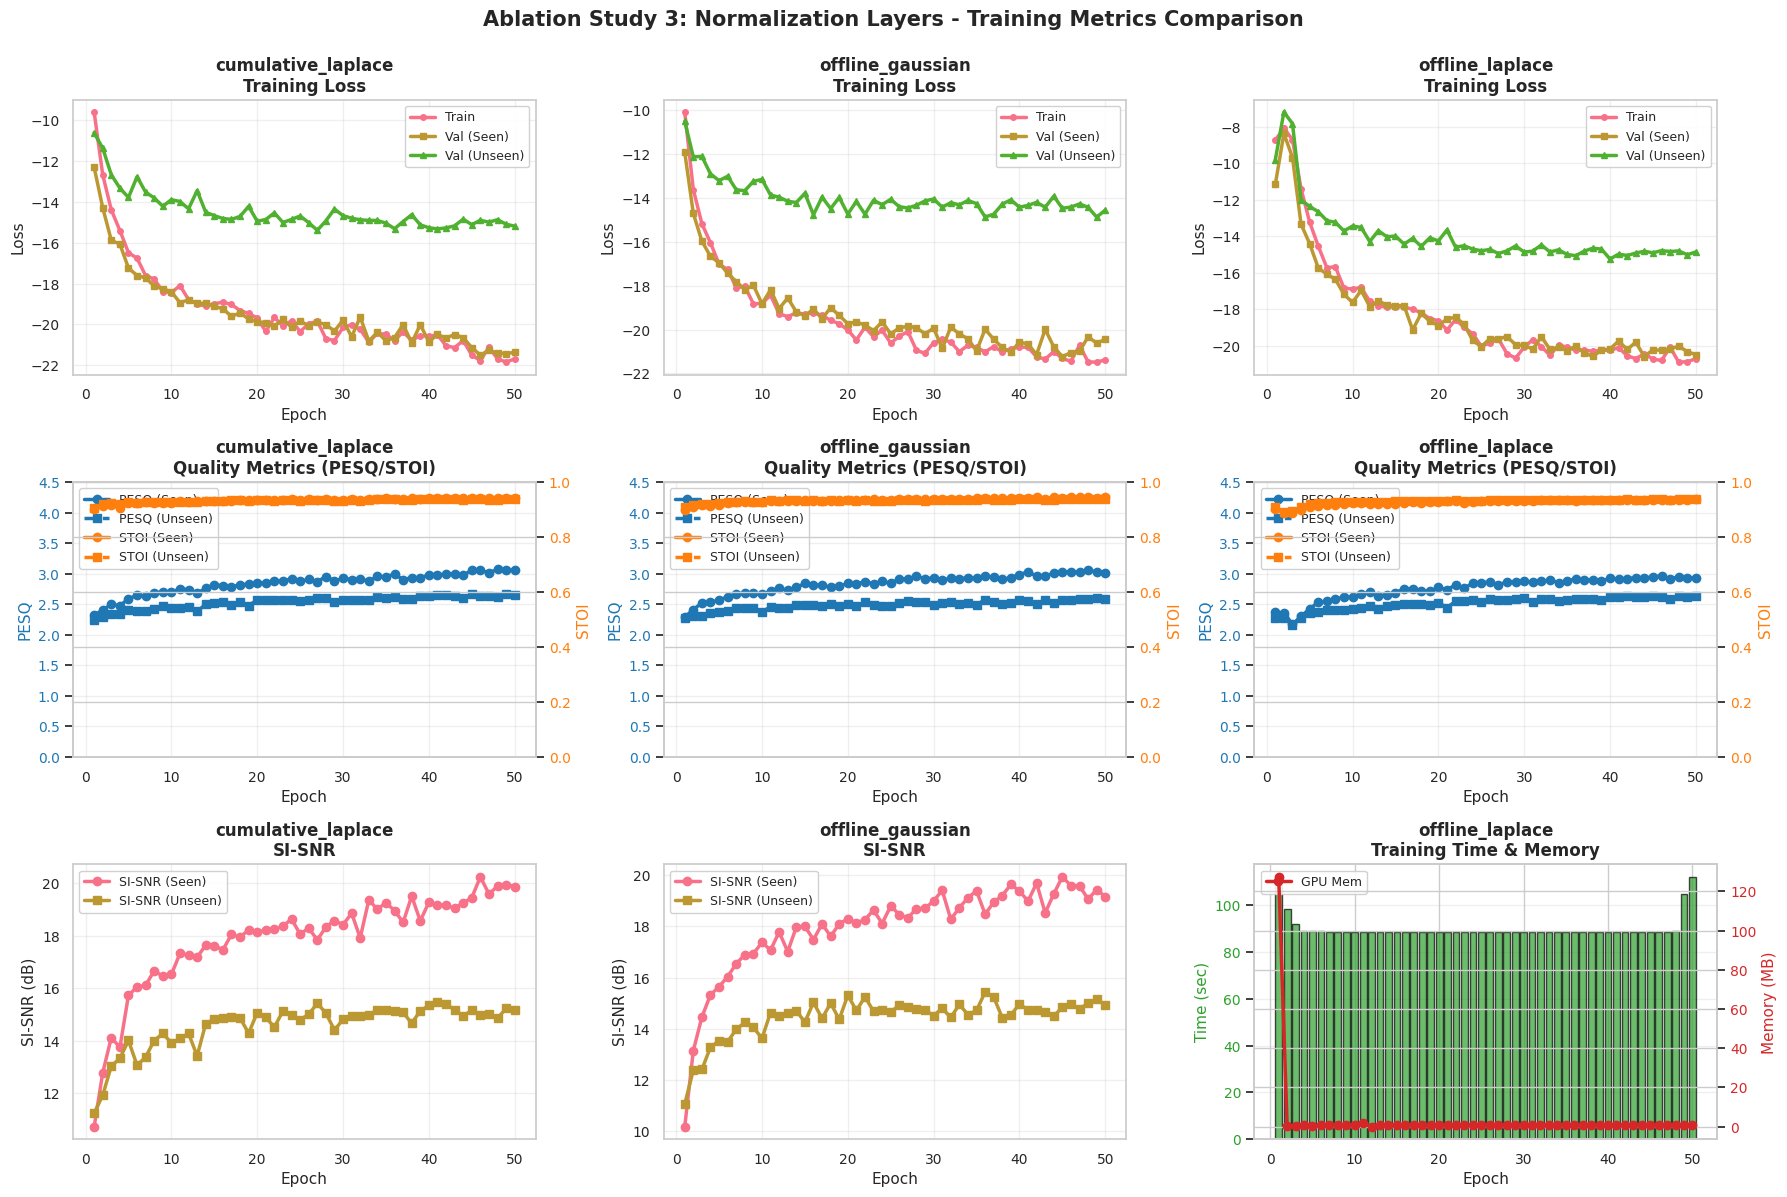


✓ Training metrics comparison saved to: ../plots/architecture_ablation_3/training_metrics_comparison.png


In [16]:
if len(training_histories) > 0:
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    num_experiments = len(training_histories)
    experiment_names = list(training_histories.keys())
    
    # Create figure with subplots for each metric
    fig, axes = plt.subplots(3, num_experiments, figsize=(6*num_experiments, 12))
    
    # Handle single experiment case (axes won't be 2D)
    if num_experiments == 1:
        axes = axes.reshape(3, 1)
    
    for col, (exp_name, history) in enumerate(training_histories.items()):
        epochs = range(1, len(history['train_loss']) + 1)
        
        # Row 1: Loss Comparison
        axes[0, col].plot(epochs, history['train_loss'], label='Train', linewidth=2.5, marker='o', markersize=4)
        axes[0, col].plot(epochs, history['val_seen_loss'], label='Val (Seen)', linewidth=2.5, marker='s', markersize=4)
        axes[0, col].plot(epochs, history['val_unseen_loss'], label='Val (Unseen)', linewidth=2.5, marker='^', markersize=4)
        axes[0, col].set_xlabel('Epoch', fontsize=11)
        axes[0, col].set_ylabel('Loss', fontsize=11)
        axes[0, col].set_title(f'{exp_name}\nTraining Loss', fontweight='bold', fontsize=12)
        axes[0, col].legend(fontsize=9, framealpha=0.9)
        axes[0, col].grid(True, alpha=0.3)
        
        # Row 2: Metrics (PESQ, STOI, SI-SNR normalized)
        ax_pesq = axes[1, col]
        ax_pesq.plot(epochs, history['val_seen_pesq'], label='PESQ (Seen)', linewidth=2.5, marker='o', color='#1f77b4')
        ax_pesq.plot(epochs, history['val_unseen_pesq'], label='PESQ (Unseen)', linewidth=2.5, marker='s', color='#1f77b4', linestyle='--')
        ax_pesq.set_xlabel('Epoch', fontsize=11)
        ax_pesq.set_ylabel('PESQ', fontsize=11, color='#1f77b4')
        ax_pesq.tick_params(axis='y', labelcolor='#1f77b4')
        ax_pesq.set_ylim([0, 4.5])
        ax_pesq.grid(True, alpha=0.3)
        
        ax_stoi = ax_pesq.twinx()
        ax_stoi.plot(epochs, history['val_seen_stoi'], label='STOI (Seen)', linewidth=2.5, marker='o', color='#ff7f0e')
        ax_stoi.plot(epochs, history['val_unseen_stoi'], label='STOI (Unseen)', linewidth=2.5, marker='s', color='#ff7f0e', linestyle='--')
        ax_stoi.set_ylabel('STOI', fontsize=11, color='#ff7f0e')
        ax_stoi.tick_params(axis='y', labelcolor='#ff7f0e')
        ax_stoi.set_ylim([0, 1])
        
        axes[1, col].set_title(f'{exp_name}\nQuality Metrics (PESQ/STOI)', fontweight='bold', fontsize=12)
        lines1, labels1 = ax_pesq.get_legend_handles_labels()
        lines2, labels2 = ax_stoi.get_legend_handles_labels()
        ax_pesq.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left', framealpha=0.9)
        
        # Row 3: Time and Memory (if available)
        if 'epoch_time' in history and len(history['epoch_time']) > 0:
            ax_time = axes[2, col]
            ax_time.bar(epochs, history['epoch_time'], color='#2ca02c', alpha=0.7, edgecolor='black', linewidth=1)
            ax_time.set_xlabel('Epoch', fontsize=11)
            ax_time.set_ylabel('Time (sec)', fontsize=11, color='#2ca02c')
            ax_time.tick_params(axis='y', labelcolor='#2ca02c')
            ax_time.grid(True, alpha=0.3, axis='y')
            
            if 'gpu_memory' in history and len(history['gpu_memory']) > 0:
                ax_mem = ax_time.twinx()
                ax_mem.plot(epochs, history['gpu_memory'], label='GPU Mem', linewidth=2.5, marker='o', color='#d62728')
                ax_mem.set_ylabel('Memory (MB)', fontsize=11, color='#d62728')
                ax_mem.tick_params(axis='y', labelcolor='#d62728')
                
                axes[2, col].set_title(f'{exp_name}\nTraining Time & Memory', fontweight='bold', fontsize=12)
                lines1, labels1 = ax_time.get_legend_handles_labels()
                lines2, labels2 = ax_mem.get_legend_handles_labels()
                ax_time.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left', framealpha=0.9)
            else:
                axes[2, col].set_title(f'{exp_name}\nTraining Time', fontweight='bold', fontsize=12)
        else:
            # SI-SNR if no time metrics
            axes[2, col].plot(epochs, history['val_seen_si_snr'], label='SI-SNR (Seen)', linewidth=2.5, marker='o')
            axes[2, col].plot(epochs, history['val_unseen_si_snr'], label='SI-SNR (Unseen)', linewidth=2.5, marker='s')
            axes[2, col].set_xlabel('Epoch', fontsize=11)
            axes[2, col].set_ylabel('SI-SNR (dB)', fontsize=11)
            axes[2, col].set_title(f'{exp_name}\nSI-SNR', fontweight='bold', fontsize=12)
            axes[2, col].legend(fontsize=9, framealpha=0.9)
            axes[2, col].grid(True, alpha=0.3)
    
    plt.suptitle(f'Ablation Study {CURRENT_ABLATION}: {ABLATION_NAME} - Training Metrics Comparison', 
                 fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    plot_file = Path(f"../plots/architecture_ablation_{CURRENT_ABLATION}/training_metrics_comparison.png")
    plot_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Training metrics comparison saved to: {plot_file}")


In [17]:
if len(training_histories) > 0:
    # Create summary table
    summary_data = []
    
    for exp_name, history in training_histories.items():
        # Get final metrics
        final_train_loss = history['train_loss'][-1]
        final_val_seen_loss = history['val_seen_loss'][-1]
        final_val_unseen_loss = history['val_unseen_loss'][-1]
        
        best_val_seen_pesq = max(history['val_seen_pesq'])
        best_val_unseen_pesq = max(history['val_unseen_pesq'])
        best_val_seen_stoi = max(history['val_seen_stoi'])
        best_val_unseen_stoi = max(history['val_unseen_stoi'])
        best_val_seen_si_snr = max(history['val_seen_si_snr'])
        best_val_unseen_si_snr = max(history['val_unseen_si_snr'])
        
        # Generalization gaps (best seen - best unseen)
        gap_pesq = best_val_seen_pesq - best_val_unseen_pesq
        gap_stoi = best_val_seen_stoi - best_val_unseen_stoi
        gap_si_snr = best_val_seen_si_snr - best_val_unseen_si_snr
        
        # Resource metrics
        total_time = sum(history['epoch_time']) if 'epoch_time' in history else None
        avg_time = np.mean(history['epoch_time']) if 'epoch_time' in history else None
        max_memory = max(history['gpu_memory']) if 'gpu_memory' in history else None
        
        summary_data.append({
            'Experiment': exp_name,
            'Final Train Loss': f"{final_train_loss:.6f}",
            'Final Val Loss (Seen)': f"{final_val_seen_loss:.6f}",
            'Final Val Loss (Unseen)': f"{final_val_unseen_loss:.6f}",
            'Best PESQ (Seen)': f"{best_val_seen_pesq:.3f}",
            'Best PESQ (Unseen)': f"{best_val_unseen_pesq:.3f}",
            'PESQ Gap': f"{gap_pesq:.3f}",
            'Best STOI (Seen)': f"{best_val_seen_stoi:.3f}",
            'Best STOI (Unseen)': f"{best_val_unseen_stoi:.3f}",
            'STOI Gap': f"{gap_stoi:.3f}",
            'Best SI-SNR Seen (dB)': f"{best_val_seen_si_snr:.2f}",
            'Best SI-SNR Unseen (dB)': f"{best_val_unseen_si_snr:.2f}",
            'SI-SNR Gap (dB)': f"{gap_si_snr:.2f}",
            'Total Time (min)': f"{total_time/60:.1f}" if total_time else "N/A",
            'Avg Time/Epoch (sec)': f"{avg_time:.2f}" if avg_time else "N/A",
            'Max Memory (MB)': f"{max_memory:.1f}" if max_memory else "N/A",
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*150)
    print(f"ABLATION STUDY {CURRENT_ABLATION}: {ABLATION_NAME}")
    print("DETAILED TRAINING METRICS SUMMARY")
    print("="*150)
    print()
    print(summary_df.to_string(index=False))
    print()
    
    # Save to CSV
    summary_file = Path(f"../results/fullsubnet_architecture_ablation_{CURRENT_ABLATION}/training_metrics_summary.csv")
    summary_file.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_file, index=False)
    print(f"✓ Summary saved to: {summary_file}")
    print("="*150)



ABLATION STUDY 3: Normalization Layers
DETAILED TRAINING METRICS SUMMARY

        Experiment Final Train Loss Final Val Loss (Seen) Final Val Loss (Unseen) Best PESQ (Seen) Best PESQ (Unseen) PESQ Gap Best STOI (Seen) Best STOI (Unseen) STOI Gap Best SI-SNR Seen (dB) Best SI-SNR Unseen (dB) SI-SNR Gap (dB) Total Time (min) Avg Time/Epoch (sec) Max Memory (MB)
cumulative_laplace       -21.680539            -21.358218              -15.196628            3.072              2.661    0.411            0.943              0.939    0.005                 20.25                   15.47            4.79              N/A                  N/A             N/A
  offline_gaussian       -21.379638            -20.445834              -14.546724            3.059              2.602    0.457            0.945              0.939    0.006                 19.94                   15.43            4.51              N/A                  N/A             N/A
   offline_laplace       -20.715081            -20.494648    

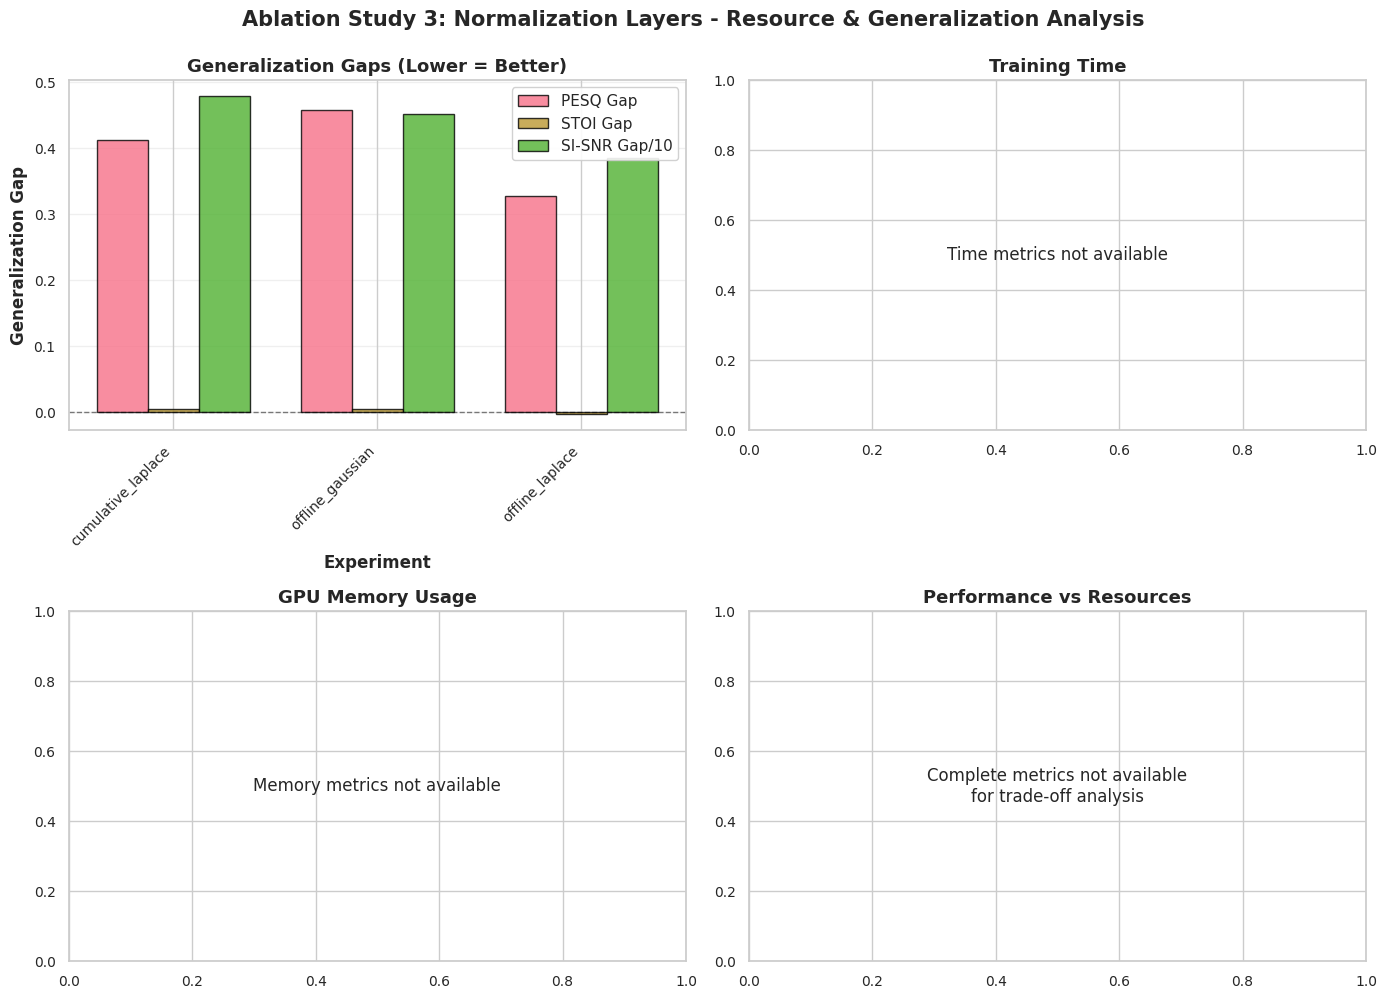


✓ Resource comparison saved to: ../plots/architecture_ablation_3/resource_comparison.png


In [18]:
if len(training_histories) > 0:
    # Create resource comparison figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    experiment_names = list(training_histories.keys())
    
    # Extract metrics for comparison
    generalization_gaps_pesq = []
    generalization_gaps_stoi = []
    generalization_gaps_si_snr = []
    total_times = []
    max_memories = []
    
    for exp_name, history in training_histories.items():
        best_pesq_seen = max(history['val_seen_pesq'])
        best_pesq_unseen = max(history['val_unseen_pesq'])
        generalization_gaps_pesq.append(best_pesq_seen - best_pesq_unseen)
        
        best_stoi_seen = max(history['val_seen_stoi'])
        best_stoi_unseen = max(history['val_unseen_stoi'])
        generalization_gaps_stoi.append(best_stoi_seen - best_stoi_unseen)
        
        best_si_snr_seen = max(history['val_seen_si_snr'])
        best_si_snr_unseen = max(history['val_unseen_si_snr'])
        generalization_gaps_si_snr.append(best_si_snr_seen - best_si_snr_unseen)
        
        if 'epoch_time' in history:
            total_times.append(sum(history['epoch_time']) / 60)  # Convert to minutes
        else:
            total_times.append(None)
        
        if 'gpu_memory' in history:
            max_memories.append(max(history['gpu_memory']))
        else:
            max_memories.append(None)
    
    x = np.arange(len(experiment_names))
    width = 0.25
    
    # Plot 1: Generalization Gaps
    axes[0, 0].bar(x - width, generalization_gaps_pesq, width, label='PESQ Gap', alpha=0.8, edgecolor='black')
    axes[0, 0].bar(x, generalization_gaps_stoi, width, label='STOI Gap', alpha=0.8, edgecolor='black')
    axes[0, 0].bar(x + width, [g/10 for g in generalization_gaps_si_snr], width, label='SI-SNR Gap/10', alpha=0.8, edgecolor='black')
    axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[0, 0].set_xlabel('Experiment', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Generalization Gap', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Generalization Gaps (Lower = Better)', fontweight='bold', fontsize=13)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(experiment_names, rotation=45, ha='right')
    axes[0, 0].legend(fontsize=11, framealpha=0.9)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Training Time
    if all(t is not None for t in total_times):
        colors_time = sns.color_palette("viridis", len(experiment_names))
        axes[0, 1].bar(experiment_names, total_times, color=colors_time, alpha=0.8, edgecolor='black', linewidth=1)
        axes[0, 1].set_ylabel('Total Training Time (minutes)', fontsize=12, fontweight='bold')
        axes[0, 1].set_title('Training Efficiency (Lower = Better)', fontweight='bold', fontsize=13)
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(total_times):
            axes[0, 1].text(i, v + 0.5, f'{v:.1f}m', ha='center', fontweight='bold', fontsize=10)
        plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        axes[0, 1].text(0.5, 0.5, 'Time metrics not available', ha='center', va='center', 
                       transform=axes[0, 1].transAxes, fontsize=12)
        axes[0, 1].set_title('Training Time', fontweight='bold', fontsize=13)
    
    # Plot 3: GPU Memory Usage
    if all(m is not None for m in max_memories):
        colors_mem = sns.color_palette("coolwarm", len(experiment_names))
        axes[1, 0].bar(experiment_names, max_memories, color=colors_mem, alpha=0.8, edgecolor='black', linewidth=1)
        axes[1, 0].set_ylabel('Peak GPU Memory (MB)', fontsize=12, fontweight='bold')
        axes[1, 0].set_title('Memory Usage (Lower = Better)', fontweight='bold', fontsize=13)
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(max_memories):
            axes[1, 0].text(i, v + 5, f'{v:.0f}MB', ha='center', fontweight='bold', fontsize=10)
        plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        axes[1, 0].text(0.5, 0.5, 'Memory metrics not available', ha='center', va='center',
                       transform=axes[1, 0].transAxes, fontsize=12)
        axes[1, 0].set_title('GPU Memory Usage', fontweight='bold', fontsize=13)
    
    # Plot 4: Performance vs Resource Trade-off
    if all(t is not None for t in total_times) and all(m is not None for m in max_memories):
        # Use average of normalized gaps as performance metric (lower is better)
        performance = []
        for i in range(len(experiment_names)):
            avg_gap = (generalization_gaps_pesq[i] + generalization_gaps_stoi[i] + generalization_gaps_si_snr[i]/10) / 3
            performance.append(avg_gap)
        
        scatter = axes[1, 1].scatter(total_times, max_memories, s=300, c=performance, 
                                    cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=2)
        
        for i, exp_name in enumerate(experiment_names):
            axes[1, 1].annotate(exp_name, (total_times[i], max_memories[i]), 
                               xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')
        
        axes[1, 1].set_xlabel('Total Training Time (minutes)', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Peak GPU Memory (MB)', fontsize=12, fontweight='bold')
        axes[1, 1].set_title('Performance vs Resource Trade-off\n(Color = Avg Generalization Gap)', 
                            fontweight='bold', fontsize=13)
        axes[1, 1].grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter, ax=axes[1, 1])
        cbar.set_label('Avg Gap (lower = better)', fontsize=11, fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'Complete metrics not available\nfor trade-off analysis', 
                       ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
        axes[1, 1].set_title('Performance vs Resources', fontweight='bold', fontsize=13)
    
    plt.suptitle(f'Ablation Study {CURRENT_ABLATION}: {ABLATION_NAME} - Resource & Generalization Analysis', 
                 fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    plot_file = Path(f"../plots/architecture_ablation_{CURRENT_ABLATION}/resource_comparison.png")
    plot_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Resource comparison saved to: {plot_file}")


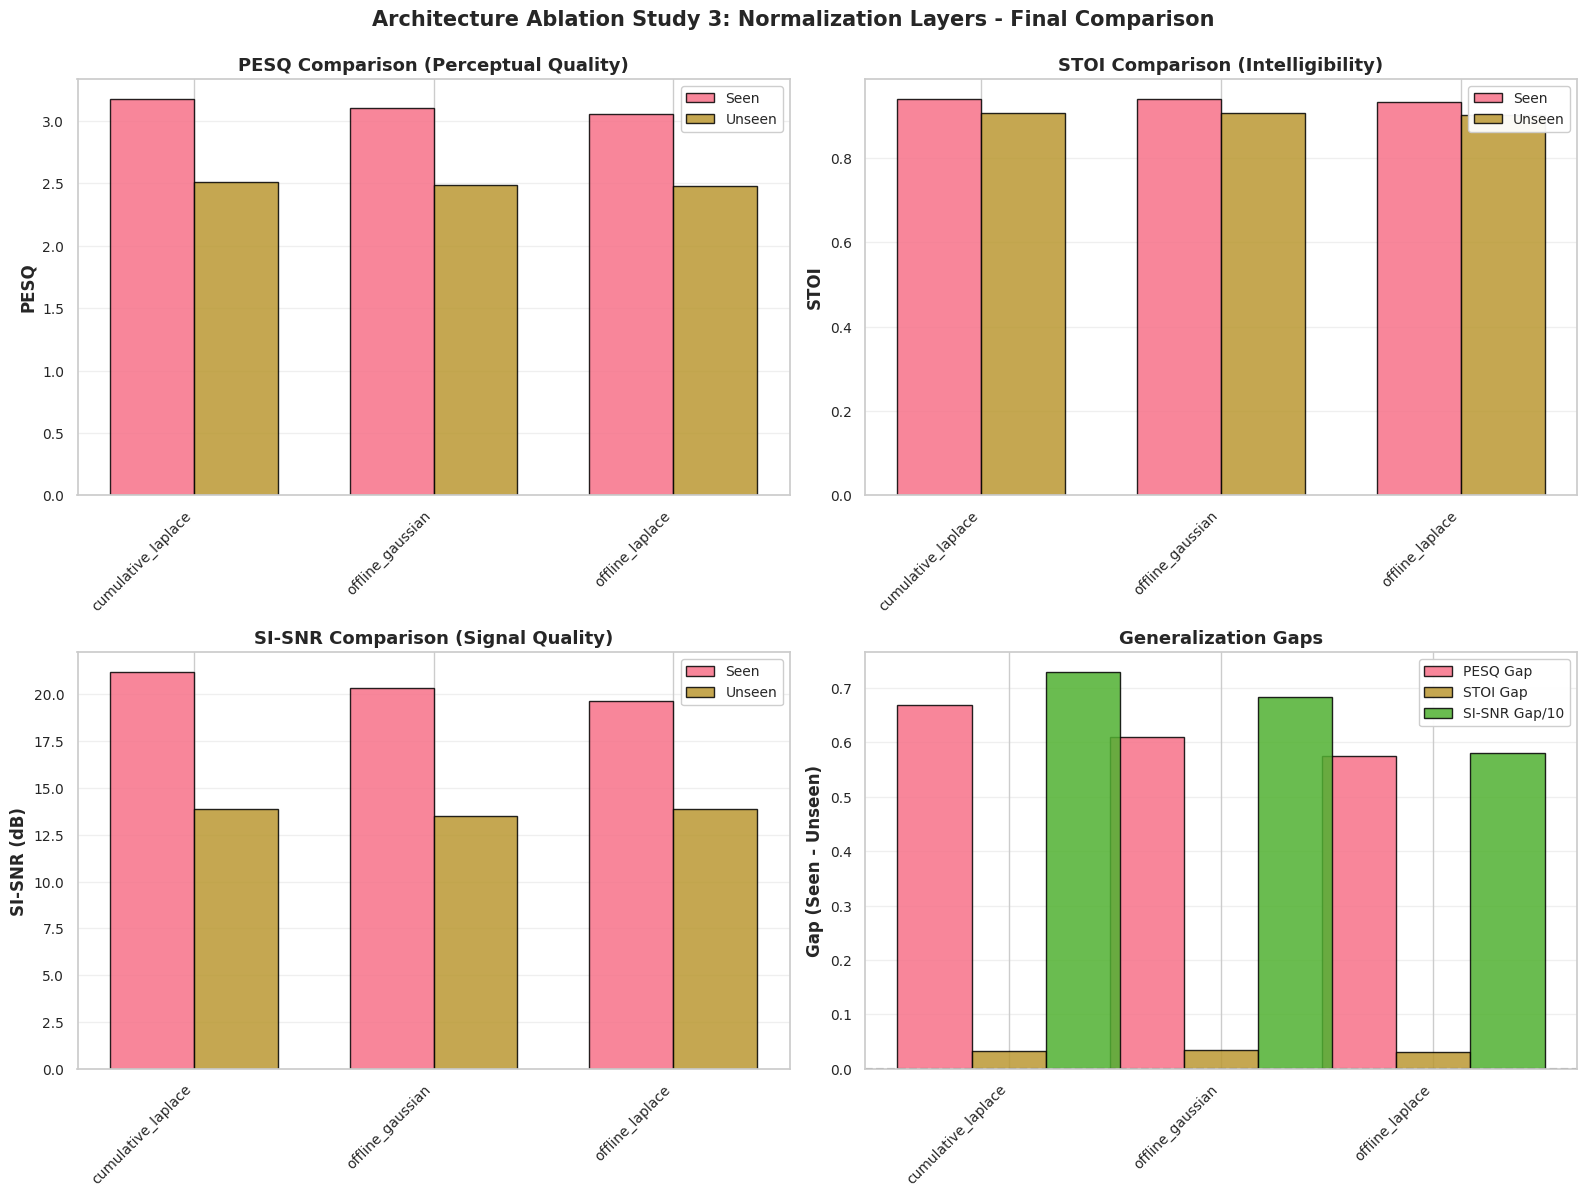


✓ Comparison plot saved to: ../plots/architecture_ablation_3/comparison_plot.png


In [19]:
if len(results_df) > 0:
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Prepare x positions
    x = np.arange(len(results_df))
    width = 0.35
    
    # Plot 1: PESQ Comparison
    axes[0, 0].bar(x - width/2, results_df['seen_pesq'], width, label='Seen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[0, 0].bar(x + width/2, results_df['unseen_pesq'], width, label='Unseen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[0, 0].set_ylabel('PESQ', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('PESQ Comparison (Perceptual Quality)', fontweight='bold', fontsize=13)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(results_df['experiment'], rotation=45, ha='right')
    axes[0, 0].legend(framealpha=0.95)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: STOI Comparison
    axes[0, 1].bar(x - width/2, results_df['seen_stoi'], width, label='Seen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[0, 1].bar(x + width/2, results_df['unseen_stoi'], width, label='Unseen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[0, 1].set_ylabel('STOI', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('STOI Comparison (Intelligibility)', fontweight='bold', fontsize=13)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(results_df['experiment'], rotation=45, ha='right')
    axes[0, 1].legend(framealpha=0.95)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: SI-SNR Comparison
    axes[1, 0].bar(x - width/2, results_df['seen_si_snr'], width, label='Seen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[1, 0].bar(x + width/2, results_df['unseen_si_snr'], width, label='Unseen', alpha=0.85, edgecolor='black', linewidth=1)
    axes[1, 0].set_ylabel('SI-SNR (dB)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('SI-SNR Comparison (Signal Quality)', fontweight='bold', fontsize=13)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(results_df['experiment'], rotation=45, ha='right')
    axes[1, 0].legend(framealpha=0.95)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Generalization Gaps
    axes[1, 1].bar(x - width, results_df['gap_pesq'], width, label='PESQ Gap', alpha=0.85, edgecolor='black', linewidth=1)
    axes[1, 1].bar(x, results_df['gap_stoi'], width, label='STOI Gap', alpha=0.85, edgecolor='black', linewidth=1)
    axes[1, 1].bar(x + width, results_df['gap_si_snr']/10, width, label='SI-SNR Gap/10', alpha=0.85, edgecolor='black', linewidth=1)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    axes[1, 1].set_ylabel('Gap (Seen - Unseen)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Generalization Gaps', fontweight='bold', fontsize=13)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(results_df['experiment'], rotation=45, ha='right')
    axes[1, 1].legend(framealpha=0.95)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Architecture Ablation Study {CURRENT_ABLATION}: {ABLATION_NAME} - Final Comparison', 
                 fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'../plots/architecture_ablation_{CURRENT_ABLATION}/comparison_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Comparison plot saved to: ../plots/architecture_ablation_{CURRENT_ABLATION}/comparison_plot.png")
else:
    print("No results to visualize yet.")

## Summary Statistics

In [20]:
if len(results_df) > 0:
    print("\n" + "="*80)
    print(f"ABLATION STUDY {CURRENT_ABLATION}: {ABLATION_NAME}")
    print("BEST RESULTS BY METRIC")
    print("="*80)
    
    print(f"\n{'PESQ Metrics:':<20}")
    print(f"  Best PESQ (Seen):   {results_df.loc[results_df['seen_pesq'].idxmax(), 'experiment']:<25} = {results_df['seen_pesq'].max():.3f}")
    print(f"  Best PESQ (Unseen): {results_df.loc[results_df['unseen_pesq'].idxmax(), 'experiment']:<25} = {results_df['unseen_pesq'].max():.3f}")
    
    print(f"\n{'STOI Metrics:':<20}")
    print(f"  Best STOI (Seen):   {results_df.loc[results_df['seen_stoi'].idxmax(), 'experiment']:<25} = {results_df['seen_stoi'].max():.3f}")
    print(f"  Best STOI (Unseen): {results_df.loc[results_df['unseen_stoi'].idxmax(), 'experiment']:<25} = {results_df['unseen_stoi'].max():.3f}")
    
    print(f"\n{'SI-SNR Metrics:':<20}")
    print(f"  Best SI-SNR (Seen):   {results_df.loc[results_df['seen_si_snr'].idxmax(), 'experiment']:<25} = {results_df['seen_si_snr'].max():.2f} dB")
    print(f"  Best SI-SNR (Unseen): {results_df.loc[results_df['unseen_si_snr'].idxmax(), 'experiment']:<25} = {results_df['unseen_si_snr'].max():.2f} dB")
    
    print(f"\n{'Generalization Gaps (Lower = Better):':<40}")
    print(f"  Smallest PESQ Gap: {results_df.loc[results_df['gap_pesq'].abs().idxmin(), 'experiment']:<25} = {results_df.loc[results_df['gap_pesq'].abs().idxmin(), 'gap_pesq']:+.3f}")
    print(f"  Smallest STOI Gap: {results_df.loc[results_df['gap_stoi'].abs().idxmin(), 'experiment']:<25} = {results_df.loc[results_df['gap_stoi'].abs().idxmin(), 'gap_stoi']:+.3f}")
    print(f"  Smallest SI-SNR Gap: {results_df.loc[results_df['gap_si_snr'].abs().idxmin(), 'experiment']:<25} = {results_df.loc[results_df['gap_si_snr'].abs().idxmin(), 'gap_si_snr']:+.2f} dB")
    
    print("\n" + "="*80)


ABLATION STUDY 3: Normalization Layers
BEST RESULTS BY METRIC

PESQ Metrics:       
  Best PESQ (Seen):   cumulative_laplace        = 3.179
  Best PESQ (Unseen): cumulative_laplace        = 2.511

STOI Metrics:       
  Best STOI (Seen):   cumulative_laplace        = 0.941
  Best STOI (Unseen): cumulative_laplace        = 0.907

SI-SNR Metrics:     
  Best SI-SNR (Seen):   cumulative_laplace        = 21.19 dB
  Best SI-SNR (Unseen): cumulative_laplace        = 13.89 dB

Generalization Gaps (Lower = Better):   
  Smallest PESQ Gap: offline_laplace           = +0.574
  Smallest STOI Gap: offline_laplace           = +0.031
  Smallest SI-SNR Gap: offline_laplace           = +5.81 dB

